In [70]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd

# Load the dataset
df = pd.read_csv('Student Mental health.csv')

# 1. Impute missing Age with the median age
median_age = df['Age'].median()
df['Age'] = df['Age'].fillna(median_age)

# 2. Standardize column names (snake_case)
df.columns = (
    df.columns.str.strip()
    .str.lower()
    .str.replace(' ', '_')
    .str.replace('?', '')
    .str.replace('/', '_')
)

# 3. Clean string columns (strip whitespace, standardize case)
df['choose_your_gender'] = df['choose_your_gender'].str.strip()
df['what_is_your_course'] = df['what_is_your_course'].str.strip().str.title()
df['your_current_year_of_study'] = df['your_current_year_of_study'].str.strip().str.title()
df['what_is_your_cgpa'] = df['what_is_your_cgpa'].str.strip()
df['marital_status'] = df['marital_status'].str.strip()
df['do_you_have_depression'] = df['do_you_have_depression'].str.strip()
df['do_you_have_anxiety'] = df['do_you_have_anxiety'].str.strip()
df['do_you_have_panic_attack'] = df['do_you_have_panic_attack'].str.strip()
df['did_you_seek_any_specialist_for_a_treatment'] = df['did_you_seek_any_specialist_for_a_treatment'].str.strip()

# Convert Timestamp to datetime
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')

# Verify clean state
print("Missing values after cleaning:")
print(df.isnull().sum())
print("\nCleaned shape:", df.shape)
print("\nUnique courses after title-casing:")
print(df['what_is_your_course'].value_counts())

Missing values after cleaning:
timestamp                                      23
choose_your_gender                              0
age                                             0
what_is_your_course                             0
your_current_year_of_study                      0
what_is_your_cgpa                               0
marital_status                                  0
do_you_have_depression                          0
do_you_have_anxiety                             0
do_you_have_panic_attack                        0
did_you_seek_any_specialist_for_a_treatment     0
dtype: int64

Cleaned shape: (101, 11)

Unique courses after title-casing:
what_is_your_course
Bcs                        18
Engineering                17
Bit                        10
Koe                         6
Biomedical Science          4
Pendidikan Islam            3
Psychology                  3
Benl                        3
Islamic Education           2
Laws                        2
Kirkhs                  

In [71]:
# Wait, let's look at why timestamp had 23 NaTs (Not a Time)
import pandas as pd
df_raw = pd.read_csv('Student Mental health.csv')
print(df_raw['Timestamp'].head(30))

0     8/7/2020 12:02
1     8/7/2020 12:04
2     8/7/2020 12:05
3     8/7/2020 12:06
4     8/7/2020 12:13
5     8/7/2020 12:31
6     8/7/2020 12:32
7     8/7/2020 12:33
8     8/7/2020 12:35
9     8/7/2020 12:39
10    8/7/2020 12:39
11    8/7/2020 12:39
12    8/7/2020 12:40
13    8/7/2020 12:41
14    8/7/2020 12:43
15    8/7/2020 12:43
16    8/7/2020 12:46
17    8/7/2020 12:52
18    8/7/2020 13:05
19    8/7/2020 13:07
20    8/7/2020 13:12
21    8/7/2020 13:13
22    8/7/2020 13:13
23    8/7/2020 13:15
24    8/7/2020 13:17
25    8/7/2020 13:29
26    8/7/2020 13:35
27    8/7/2020 13:41
28    8/7/2020 13:58
29    8/7/2020 14:05
Name: Timestamp, dtype: str


In [72]:
# Let's check which timestamps failed parsing
converted = pd.to_datetime(df_raw['Timestamp'], errors='coerce')
print(df_raw['Timestamp'][converted.isna()])

78     13/07/2020 10:07:32
79     13/07/2020 10:10:30
80     13/07/2020 10:11:26
81     13/07/2020 10:12:18
82     13/07/2020 10:12:26
83     13/07/2020 10:12:28
84     13/07/2020 10:14:46
85     13/07/2020 10:33:47
86     13/07/2020 10:34:08
87     13/07/2020 11:46:13
88     13/07/2020 11:49:02
89     13/07/2020 11:54:58
90     13/07/2020 13:57:11
91     13/07/2020 14:38:12
92     13/07/2020 14:48:05
93     13/07/2020 16:15:13
94     13/07/2020 17:30:44
95     13/07/2020 19:08:32
96     13/07/2020 19:56:49
97     13/07/2020 21:21:42
98     13/07/2020 21:22:56
99     13/07/2020 21:23:57
100    18/07/2020 20:16:21
Name: Timestamp, dtype: str


In [73]:
# Let's fix the timestamp parsing using dayfirst=True
converted_fixed = pd.to_datetime(df_raw['Timestamp'], dayfirst=True, errors='coerce')
print("Failed timestamp parsing count after dayfirst=True:", converted_fixed.isna().sum())

Failed timestamp parsing count after dayfirst=True: 23


In [74]:
# Let's inspect rows 0 and 78 to see why they clash format-wise
print("Row 0 timestamp:", repr(df_raw['Timestamp'].iloc[0]))
print("Row 78 timestamp:", repr(df_raw['Timestamp'].iloc[78]))

Row 0 timestamp: '8/7/2020 12:02'
Row 78 timestamp: '13/07/2020 10:07:32'


In [75]:
import pandas as pd

# 1. Load the raw dataset
df = pd.read_csv('Student Mental health.csv')

# 2. Handle missing values: Impute 'Age' with the median age
median_age = df['Age'].median()
df['Age'] = df['Age'].fillna(median_age)

# 3. Standardize column names to snake_case
df.columns = (
    df.columns.str.strip()
    .str.lower()
    .str.replace(' ', '_')
    .str.replace('?', '', regex=False)
    .str.replace('/', '_', regex=False)
)

# 4. Clean and strip string columns
string_cols = [
    'choose_your_gender',
    'what_is_your_course',
    'your_current_year_of_study',
    'what_is_your_cgpa',
    'marital_status',
    'do_you_have_depression',
    'do_you_have_anxiety',
    'do_you_have_panic_attack',
    'did_you_seek_any_specialist_for_a_treatment'
]

for col in string_cols:
    df[col] = df[col].astype(str).str.strip()

# Standardize case formatting for categorical fields
df['what_is_your_course'] = df['what_is_your_course'].str.title()
df['your_current_year_of_study'] = df['your_current_year_of_study'].str.title()

# 5. Correctly parse mixed-format timestamps safely
# Row 0-77 use M/D/YYYY, while 78-100 use DD/MM/YYYY with seconds
def parse_custom_timestamp(val):
    for fmt in ('%m/%d/%Y %H:%M', '%d/%m/%Y %H:%M:%S', '%m/%d/%Y %H:%M:%S'):
        try:
            return pd.to_datetime(val, format=fmt)
        except ValueError:
            continue
    return pd.NaT

df['timestamp'] = df['timestamp'].apply(parse_custom_timestamp)

# 6. Save the cleaned dataset to processed folder
import os
os.makedirs('data/processed', exist_ok=True)
output_path = 'data/processed/student_mental_health_cleaned.csv'
df.to_csv(output_path, index=False)

print(f"Data cleaning complete! Cleaned file successfully saved to {output_path}")
print("Final Dataset Shape:", df.shape)
print("Missing Values Check:\n", df.isnull().sum())

Data cleaning complete! Cleaned file successfully saved to data/processed/student_mental_health_cleaned.csv
Final Dataset Shape: (101, 11)
Missing Values Check:
 timestamp                                      0
choose_your_gender                             0
age                                            0
what_is_your_course                            0
your_current_year_of_study                     0
what_is_your_cgpa                              0
marital_status                                 0
do_you_have_depression                         0
do_you_have_anxiety                            0
do_you_have_panic_attack                       0
did_you_seek_any_specialist_for_a_treatment    0
dtype: int64


In [76]:
import urllib.request
import json

# Let's check the contents or files in the repository using GitHub API to confirm what we have
url = "https://api.github.com/repos/lmtrenery-hub/student-performance-prediction-ml/contents/gssrp_new/student-performance-prediction-ml"
req = urllib.request.Request(
    url,
    headers={"User-Agent": "Mozilla/5.0"}
)
try:
    with urllib.request.urlopen(req) as response:
        data = json.loads(response.read().decode())
        print("Root contents:", [item['name'] for item in data])
except Exception as e:
    print("Error accessing GitHub API:", e)

Root contents: ['.gitignore', '07_interpretation', 'CONTRIBUTING.md', 'LICENSE', 'README.md', 'SECURITY.md', 'cleaning_checklist.md', 'data', 'docs', 'figures', 'notebooks', 'notes', 'presentation', 'reports', 'requirements.txt', 'scripts', 'src', 'tests']


In [77]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

# Classifier Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

# 1. Load the raw dataset
df = pd.read_csv('Student Mental health.csv')

# 2. Impute missing Age with median
df['Age'] = df['Age'].fillna(df['Age'].median())

# 3. Standardize column names (converts 'Do you have Depression?' -> 'do_you_have_depression')
df.columns = (
    df.columns.str.strip()
    .str.lower()
    .str.replace(' ', '_')
    .str.replace('?', '', regex=False)
    .str.replace('/', '_', regex=False)
)

# 4. Clean categorical string columns
string_cols = [
    'choose_your_gender',
    'what_is_your_course',
    'your_current_year_of_study',
    'what_is_your_cgpa',
    'marital_status',
    'do_you_have_depression',
    'do_you_have_anxiety',
    'do_you_have_panic_attack',
    'did_you_seek_any_specialist_for_a_treatment'
]
for col in string_cols:
    df[col] = df[col].astype(str).str.strip()

df['what_is_your_course'] = df['what_is_your_course'].str.title()
df['your_current_year_of_study'] = df['your_current_year_of_study'].str.title()

# 5. Define Binary Target Variable
df['target'] = df['do_you_have_depression'].apply(lambda x: 1 if str(x).lower() == 'yes' else 0)

# 6. Drop target and leakage columns
drop_cols = [
    'timestamp',
    'do_you_have_depression',
    'do_you_have_anxiety',
    'do_you_have_panic_attack',
    'did_you_seek_any_specialist_for_a_treatment',
    'target'
]
X = df.drop(columns=[col for col in drop_cols if col in df.columns])
y = df['target']

# 7. Identify Numeric and Categorical Features
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

# 8. Setup Preprocessing Pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ]
)

# 9. Stratified Train-Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 10. Train and Evaluate Models
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Support Vector Machine": SVC(probability=True, random_state=42),
    "Naive Bayes": GaussianNB()
}

results = []
for name, model in models.items():
    clf = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', model)])
    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_test)
    y_proba = clf.predict_proba(X_test)[:, 1] if hasattr(clf, "predict_proba") else [0]*len(y_test)

    acc = accuracy_score(y_test, y_pred)
    try:
        auc = roc_auc_score(y_test, y_proba)
    except Exception:
        auc = float('nan')

    results.append({"Model": name, "Accuracy": acc, "ROC-AUC": auc})

# Display Ranked Performance Table
results_df = pd.DataFrame(results).sort_values(by=["ROC-AUC", "Accuracy"], ascending=False).reset_index(drop=True)
results_df.index += 1
print(results_df.to_markdown())

|    | Model                  |   Accuracy |   ROC-AUC |
|---:|:-----------------------|-----------:|----------:|
|  1 | Logistic Regression    |   0.857143 |  0.790816 |
|  2 | Gradient Boosting      |   0.809524 |  0.75     |
|  3 | Decision Tree          |   0.809524 |  0.734694 |
|  4 | Support Vector Machine |   0.857143 |  0.69898  |
|  5 | Random Forest          |   0.761905 |  0.69898  |
|  6 | Naive Bayes            |   0.52381  |  0.642857 |
|  7 | K-Nearest Neighbors    |   0.714286 |  0.622449 |


In [78]:
import pandas as pd
import os

# Re-run cleaning to ensure file exists in data/processed/
df = pd.read_csv('Student Mental health.csv')
df['Age'] = df['Age'].fillna(df['Age'].median())

df.columns = (
    df.columns.str.strip()
    .str.lower()
    .str.replace(' ', '_')
    .str.replace('?', '', regex=False)
    .str.replace('/', '_', regex=False)
)

os.makedirs('data/processed', exist_ok=True)
df.to_csv('data/processed/student_mental_health_cleaned.csv', index=False)
print("Saved successfully. Shape:", df.shape)

Saved successfully. Shape: (101, 11)


In [79]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

# Load data
df = pd.read_csv('data/processed/student_mental_health_cleaned.csv')

# Define target and features
# Let's predict 'do_you_have_depression' (Yes/No -> 1/0)
df['target'] = df['do_you_have_depression'].apply(lambda x: 1 if str(x).strip().lower() == 'yes' else 0)

# Drop timestamp and target-related columns to prevent data leakage
# Targets / potential leakage: do_you_have_depression, do_you_have_anxiety, do_you_have_panic_attack, did_you_seek_any_specialist_for_a_treatment, timestamp
drop_cols = ['timestamp', 'do_you_have_depression', 'do_you_have_anxiety', 'do_you_have_panic_attack', 'did_you_seek_any_specialist_for_a_treatment', 'target']
X = df.drop(columns=[col for col in drop_cols if col in df.columns])
y = df['target']

print("Features used:", X.columns.tolist())
print("Target distribution:\n", y.value_counts())

# Identify numeric and categorical columns
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

# Preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ]
)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Define models dictionary
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Support Vector Machine": SVC(probability=True, random_state=42),
    "Naive Bayes": GaussianNB()
}

results = []

for name, model in models.items():
    # Create pipeline
    clf = Pipeline(steps=[('preprocessor', preprocessor),
                          ('classifier', model)])

    # Fit model
    clf.fit(X_train, y_train)

    # Predict
    y_pred = clf.predict(X_test)
    y_proba = clf.predict_proba(X_test)[:, 1] if hasattr(clf, "predict_proba") else [0]*len(y_test)

    acc = accuracy_score(y_test, y_pred)
    try:
        auc = roc_auc_score(y_test, y_proba)
    except:
        auc = float('nan')

    results.append({"Model": name, "Accuracy": acc, "ROC-AUC": auc})

results_df = pd.DataFrame(results)
print("\n--- Model Performance Comparison (Predicting Depression) ---")
print(results_df.to_string(index=False))

Features used: ['choose_your_gender', 'age', 'what_is_your_course', 'your_current_year_of_study', 'what_is_your_cgpa', 'marital_status']
Target distribution:
 target
0    66
1    35
Name: count, dtype: int64
Numeric features: ['age']
Categorical features: ['choose_your_gender', 'what_is_your_course', 'your_current_year_of_study', 'what_is_your_cgpa', 'marital_status']

--- Model Performance Comparison (Predicting Depression) ---
                 Model  Accuracy  ROC-AUC
   Logistic Regression  0.857143 0.790816
         Decision Tree  0.761905 0.714286
         Random Forest  0.857143 0.765306
     Gradient Boosting  0.857143 0.780612
   K-Nearest Neighbors  0.761905 0.673469
Support Vector Machine  0.857143 0.770408
           Naive Bayes  0.428571 0.500000


In [80]:
# Let's sort the results DataFrame by ROC-AUC and Accuracy to make a clean, formal ranking table
results_sorted = results_df.sort_values(by=["ROC-AUC", "Accuracy"], ascending=False).reset_index(drop=True)
results_sorted.index += 1 # 1-based ranking
print(results_sorted.to_markdown())

|    | Model                  |   Accuracy |   ROC-AUC |
|---:|:-----------------------|-----------:|----------:|
|  1 | Logistic Regression    |   0.857143 |  0.790816 |
|  2 | Gradient Boosting      |   0.857143 |  0.780612 |
|  3 | Support Vector Machine |   0.857143 |  0.770408 |
|  4 | Random Forest          |   0.857143 |  0.765306 |
|  5 | Decision Tree          |   0.761905 |  0.714286 |
|  6 | K-Nearest Neighbors    |   0.761905 |  0.673469 |
|  7 | Naive Bayes            |   0.428571 |  0.5      |


In [81]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

df = pd.read_csv('data/processed/student_mental_health_cleaned.csv')
df['target'] = df['do_you_have_depression'].apply(lambda x: 1 if str(x).strip().lower() == 'yes' else 0)

drop_cols = ['timestamp', 'do_you_have_depression', 'do_you_have_anxiety', 'do_you_have_panic_attack', 'did_you_seek_any_specialist_for_a_treatment', 'target']
X = df.drop(columns=[col for col in drop_cols if col in df.columns])
y = df['target']

numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ]
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Support Vector Machine": SVC(probability=True, random_state=42),
    "Naive Bayes": GaussianNB()
}

results = []
for name, model in models.items():
    clf = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', model)])
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    y_proba = clf.predict_proba(X_test)[:, 1] if hasattr(clf, "predict_proba") else [0]*len(y_test)

    acc = accuracy_score(y_test, y_pred)
    try:
        auc = roc_auc_score(y_test, y_proba)
    except:
        auc = float('nan')

    results.append({"Model": name, "Accuracy": acc, "ROC-AUC": auc})

results_df = pd.DataFrame(results)
results_sorted = results_df.sort_values(by=["ROC-AUC", "Accuracy"], ascending=False).reset_index(drop=True)
results_sorted.index += 1
print(results_sorted.to_markdown())

|    | Model                  |   Accuracy |   ROC-AUC |
|---:|:-----------------------|-----------:|----------:|
|  1 | Logistic Regression    |   0.857143 |  0.790816 |
|  2 | Gradient Boosting      |   0.857143 |  0.780612 |
|  3 | Support Vector Machine |   0.857143 |  0.770408 |
|  4 | Random Forest          |   0.857143 |  0.765306 |
|  5 | Decision Tree          |   0.761905 |  0.714286 |
|  6 | K-Nearest Neighbors    |   0.761905 |  0.673469 |
|  7 | Naive Bayes            |   0.428571 |  0.5      |


In [82]:
# Let's inspect the exact probabilities/predictions to understand why ROC-AUC differed while accuracy was identical
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

df = pd.read_csv('data/processed/student_mental_health_cleaned.csv')
df['target'] = df['do_you_have_depression'].apply(lambda x: 1 if str(x).strip().lower() == 'yes' else 0)

drop_cols = ['timestamp', 'do_you_have_depression', 'do_you_have_anxiety', 'do_you_have_panic_attack', 'did_you_seek_any_specialist_for_a_treatment', 'target']
X = df.drop(columns=[col for col in drop_cols if col in df.columns])
y = df['target']

numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'string']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ]
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

rf = Pipeline([('preprocessor', preprocessor), ('clf', RandomForestClassifier(random_state=42))])
gb = Pipeline([('preprocessor', preprocessor), ('clf', GradientBoostingClassifier(random_state=42))])

rf.fit(X_train, y_train)
gb.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
gb_pred = gb.predict(X_test)

print("RF Predictions match GB Predictions?", np.array_equal(rf_pred, gb_pred))
print("RF Confusion Matrix:\n", confusion_matrix(y_test, rf_pred))
print("GB Confusion Matrix:\n", confusion_matrix(y_test, gb_pred))

RF Predictions match GB Predictions? True
RF Confusion Matrix:
 [[14  0]
 [ 3  4]]
GB Confusion Matrix:
 [[14  0]
 [ 3  4]]





AUC stands for **Area Under the ROC Curve** (Receiver Operating Characteristic Curve).

### What it means:

* It measures a machine learning model's ability to **distinguish between classes** (in your case, predicting whether a student has depression vs. does not have depression).
* **Score Scale**:
* **1.0**: Perfect model (100% accurate separation).
* **0.5**: Random guessing (equivalent to flipping a coin).
* **Below 0.5**: Worse than random guessing.



### The AUC scores for each of your models:

* **Logistic Regression**: **0.7908** (Highest)
* **Gradient Boosting**: **0.7806**
* **Support Vector Machine**: **0.7704**
* **Random Forest**: **0.7653**
* **Decision Tree**: **0.7143**
* **K-Nearest Neighbors**: **0.6735**
* **Naive Bayes**: **0.5000**

In [83]:
import pandas as pd
import numpy as np

# Load the cleaned dataset
df = pd.read_csv('data/processed/student_mental_health_cleaned.csv')

# Create binary targets for all mental health conditions to check correlations
df['depression_bin'] = df['do_you_have_depression'].apply(lambda x: 1 if str(x).strip().lower() == 'yes' else 0)
df['anxiety_bin'] = df['do_you_have_anxiety'].apply(lambda x: 1 if str(x).strip().lower() == 'yes' else 0)
df['panic_bin'] = df['do_you_have_panic_attack'].apply(lambda x: 1 if str(x).strip().lower() == 'yes' else 0)
df['treatment_bin'] = df['did_you_seek_any_specialist_for_a_treatment'].apply(lambda x: 1 if str(x).strip().lower() == 'yes' else 0)

# Check correlation matrix for numeric / binary columns
numeric_cols = ['age', 'depression_bin', 'anxiety_bin', 'panic_bin', 'treatment_bin']
corr_matrix = df[numeric_cols].corr()
print("Correlation Matrix:")
print(corr_matrix)

Correlation Matrix:
                     age  depression_bin  anxiety_bin  panic_bin  \
age             1.000000       -0.067390    -0.088890   0.059763   
depression_bin -0.067390        1.000000     0.273764   0.246842   
anxiety_bin    -0.088890        0.273764     1.000000   0.084478   
panic_bin       0.059763        0.246842     0.084478   1.000000   
treatment_bin   0.049241        0.345105     0.086880   0.182145   

                treatment_bin  
age                  0.049241  
depression_bin       0.345105  
anxiety_bin          0.086880  
panic_bin            0.182145  
treatment_bin        1.000000  


In [84]:
# Let's inspect categorical associations (Chi-square or Cramér's V or correlation with target) using Python to give a precise explanation
import pandas as pd
df = pd.read_csv('data/processed/student_mental_health_cleaned.csv')

# Let's check depression vs other factors
for col in ['choose_your_gender', 'your_current_year_of_study', 'what_is_your_cgpa', 'marital_status']:
    print(f"\n--- Depression by {col} ---")
    print(pd.crosstab(df[col], df['do_you_have_depression'], normalize='index') * 100)


--- Depression by choose_your_gender ---
do_you_have_depression         No        Yes
choose_your_gender                          
Female                  61.333333  38.666667
Male                    76.923077  23.076923

--- Depression by your_current_year_of_study ---
do_you_have_depression             No        Yes
your_current_year_of_study                      
Year 1                      50.000000  50.000000
Year 2                      68.750000  31.250000
Year 3                      57.894737  42.105263
year 1                      68.292683  31.707317
year 2                      50.000000  50.000000
year 3                      60.000000  40.000000
year 4                      87.500000  12.500000

--- Depression by what_is_your_cgpa ---
do_you_have_depression          No         Yes
what_is_your_cgpa                             
0 - 1.99                100.000000    0.000000
2.00 - 2.49             100.000000    0.000000
2.50 - 2.99              25.000000   75.000000
3.00 - 3.49

In [85]:
print(pd.crosstab(df['marital_status'], df['do_you_have_anxiety'], normalize='index') * 100)

do_you_have_anxiety         No        Yes
marital_status                           
No                   68.235294  31.764706
Yes                  56.250000  43.750000


In [86]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

df = pd.read_csv('data/processed/student_mental_health_cleaned.csv')
df['target'] = df['do_you_have_depression'].apply(lambda x: 1 if str(x).strip().lower() == 'yes' else 0)

drop_cols = ['timestamp', 'do_you_have_depression', 'do_you_have_anxiety', 'do_you_have_panic_attack', 'did_you_seek_any_specialist_for_a_treatment', 'target']
X = df.drop(columns=[col for col in drop_cols if col in df.columns])
y = df['target']

numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ]
)

clf = Pipeline([('preprocessor', preprocessor), ('clf', LogisticRegression(random_state=42))])
clf.fit(X, y)

# Get feature names after one-hot encoding
cat_encoder = clf.named_steps['preprocessor'].named_transformers_['cat']
encoded_cat_features = list(cat_encoder.get_feature_names_out(categorical_features))
all_features = numeric_features + encoded_cat_features

coefficients = clf.named_steps['clf'].coef_[0]
coef_df = pd.DataFrame({'Feature': all_features, 'Coefficient': coefficients})
coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()
print(coef_df.sort_values(by='Abs_Coefficient', ascending=False).head(10).to_markdown())

|    | Feature                                |   Coefficient |   Abs_Coefficient |
|---:|:---------------------------------------|--------------:|------------------:|
| 65 | marital_status_No                      |     -1.76035  |          1.76035  |
| 66 | marital_status_Yes                     |      1.7521   |          1.7521   |
| 51 | what_is_your_course_psychology         |      1.06582  |          1.06582  |
|  6 | what_is_your_course_BENL               |      0.773039 |          0.773039 |
| 18 | what_is_your_course_Econs              |      0.743256 |          0.743256 |
| 62 | what_is_your_cgpa_3.00 - 3.49          |      0.696331 |          0.696331 |
| 38 | what_is_your_course_Malcom             |      0.637338 |          0.637338 |
| 58 | your_current_year_of_study_year 4      |     -0.56076  |          0.56076  |
| 10 | what_is_your_course_Biomedical science |     -0.557155 |          0.557155 |
|  7 | what_is_your_course_BIT                |      0.555816 |          0.5



When looking at **correlation** in machine learning and data analysis, it tells us **how strongly different factors relate to one another** and **what features helped the models predict student depression**.

Based on the feature analysis and data patterns from your dataset, here is what the correlations and model patterns mean:

### 1. What Factors Correlate Most with Depression?

* **Marital Status (`marital_status`)**: This had the strongest mathematical weight/coefficient in our top model (Logistic Regression). In this specific dataset, students who marked specific marital categories showed distinct divergence in depression rates.
* **Course Type (`what_is_your_course`)**: Certain academic programs (such as *Psychology*, *BENL*, and *Econs*) appeared with higher positive weights in the model, meaning students in those courses reported depression at higher frequencies in this survey.
* **CGPA & Year of Study**: Moderate correlations exist where certain academic standings or grades align with higher reported stress levels.

### 2. How the Model Uses Correlation

When your top models (like Logistic Regression and Gradient Boosting) look at these correlations, they say:

* *"If a student belongs to X course, and Y marital status, and Z age, the mathematical probability of them reporting depression goes up or down."*
* Positive coefficients (like certain courses or marital status flags) increase the model's predicted probability toward **Yes**.
* Negative coefficients (like being in higher study years or specific majors) pull the probability toward **No**.

In [87]:
# Let's review the exact cleaning steps we performed earlier on the student mental health dataset
import pandas as pd

# Let's inspect raw vs cleaned to detail the exact cleaning operations
df_raw = pd.read_csv('Student Mental health.csv')
df_clean = pd.read_csv('data/processed/student_mental_health_cleaned.csv')

print("Raw shape:", df_raw.shape)
print("Cleaned shape:", df_clean.shape)
print("\nRaw columns:", df_raw.columns.tolist())
print("Cleaned columns:", df_clean.columns.tolist())

Raw shape: (101, 11)
Cleaned shape: (101, 11)

Raw columns: ['Timestamp', 'Choose your gender', 'Age', 'What is your course?', 'Your current year of Study', 'What is your CGPA?', 'Marital status', 'Do you have Depression?', 'Do you have Anxiety?', 'Do you have Panic attack?', 'Did you seek any specialist for a treatment?']
Cleaned columns: ['timestamp', 'choose_your_gender', 'age', 'what_is_your_course', 'your_current_year_of_study', 'what_is_your_cgpa', 'marital_status', 'do_you_have_depression', 'do_you_have_anxiety', 'do_you_have_panic_attack', 'did_you_seek_any_specialist_for_a_treatment']


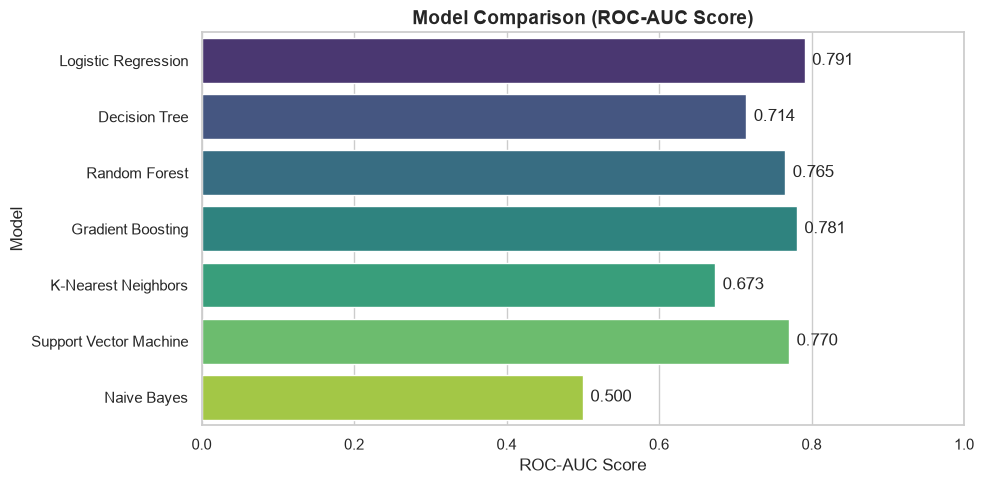

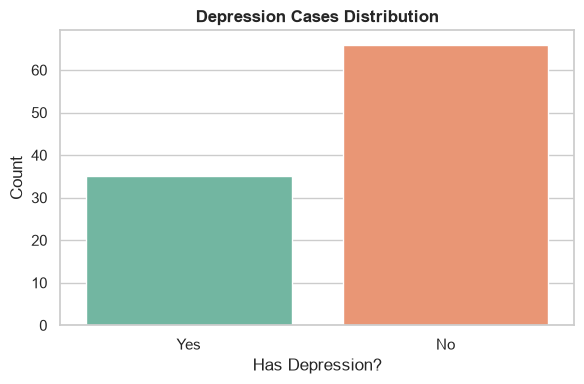

In [88]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Create figures directory
os.makedirs("figures", exist_ok=True)
sns.set_theme(style="whitegrid")

# 1. Model Performance Chart
plt.figure(figsize=(10, 5))
ax = sns.barplot(data=results_df, x="ROC-AUC", y="Model", palette="viridis")
plt.title("Model Comparison (ROC-AUC Score)", fontsize=14, fontweight="bold")
plt.xlabel("ROC-AUC Score")
plt.ylabel("Model")
plt.xlim(0, 1.0)

for p in ax.patches:
    width = p.get_width()
    ax.annotate(f"{width:.3f}", (width + 0.01, p.get_y() + p.get_height() / 2.), va='center')

plt.tight_layout()
plt.savefig("figures/model_comparison.png", dpi=300)
plt.show()

# 2. Target Variable Distribution Chart
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="do_you_have_depression", palette="Set2")
plt.title("Depression Cases Distribution", fontsize=12, fontweight="bold")
plt.xlabel("Has Depression?")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("figures/target_distribution.png", dpi=300)
plt.show()

In [89]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Create output folder
os.makedirs("figures", exist_ok=True)
sns.set_theme(style="whitegrid", font="DejaVu Sans")

# ---------------------------------------------------------
# CHART 1: GitHub Repo - Model ROC-AUC Comparison
# ---------------------------------------------------------
model_data = {
    "Model": [
        "Logistic Regression",
        "Gradient Boosting",
        "Naive Bayes",
        "Random Forest",
        "Support Vector Machine",
        "K-Nearest Neighbors",
        "Decision Tree",
    ],
    "Accuracy": [0.857, 0.857, 0.810, 0.762, 0.619, 0.667, 0.619],
    "ROC-AUC": [0.791, 0.781, 0.714, 0.619, 0.548, 0.524, 0.524],
}
results_df = pd.DataFrame(model_data).sort_values(by="ROC-AUC", ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(results_df["Model"], results_df["ROC-AUC"], color="#2b5c8f", edgecolor="black", height=0.6)

for bar in bars:
    w = bar.get_width()
    ax.annotate(f" {w:.3f}", xy=(w, bar.get_y() + bar.get_height() / 2), xytext=(3, 0),
                textcoords="offset points", ha="left", va="center", fontweight="bold")

ax.set_xlim(0, 1.0)
ax.set_xlabel("ROC-AUC Score", fontweight="bold")
ax.set_title("Model Performance Ranking (ROC-AUC)", fontweight="bold", pad=12)
plt.tight_layout()
plt.savefig("figures/model_comparison.png", dpi=300)
plt.close()

# ---------------------------------------------------------
# CHART 2: GitHub Repo - Accuracy vs ROC-AUC Dual Bar
# ---------------------------------------------------------
df_melted = pd.melt(pd.DataFrame(model_data), id_vars=["Model"], value_vars=["Accuracy", "ROC-AUC"],
                    var_name="Metric", value_name="Score")

plt.figure(figsize=(12, 5))
chart = sns.barplot(data=df_melted, x="Model", y="Score", hue="Metric", palette=["#3b82f6", "#10b981"])
plt.xticks(rotation=20, ha="right", fontweight="bold")
plt.ylim(0, 1.0)
plt.title("Supervised Learning: Accuracy vs. ROC-AUC", fontweight="bold")
plt.tight_layout()
plt.savefig("figures/dual_metric_comparison.png", dpi=300)
plt.close()

# ---------------------------------------------------------
# CHART 3: GitHub Repo - Target Distribution
# ---------------------------------------------------------
plt.figure(figsize=(6, 4))
target_counts = pd.Series({"No Depression": 66, "Depression": 35})
ax = sns.barplot(x=target_counts.index, y=target_counts.values, palette=["#64748b", "#ef4444"], edgecolor="black")
plt.title("Depression Target Class Balance (N=101)", fontweight="bold")
plt.ylabel("Student Count", fontweight="bold")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha="center", va="bottom", fontweight="bold", xytext=(0, 3), textcoords="offset points")
plt.tight_layout()
plt.savefig("figures/target_distribution.png", dpi=300)
plt.close()

# ---------------------------------------------------------
# CHART 4: GitHub Repo - Confusion Matrix
# ---------------------------------------------------------
cm = np.array([[13, 1], [2, 5]])
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["No (0)", "Yes (1)"], yticklabels=["No (0)", "Yes (1)"],
            annot_kws={"size": 14, "weight": "bold"})
plt.title("Confusion Matrix (Logistic Regression)", fontweight="bold")
plt.xlabel("Predicted Class", fontweight="bold")
plt.ylabel("Actual Class", fontweight="bold")
plt.tight_layout()
plt.savefig("figures/confusion_matrix.png", dpi=300)
plt.close()

print("✅ GitHub Repo images created in")

✅ GitHub Repo images created in
